1. Thu thập dữ liệu (Tìm dataset)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['font.size'] = 11

#  Đọc dữ liệu rating (u.data) 
ratings = pd.read_csv(
    'u.data',
    sep='\t',
    names=['user_id', 'movie_id', 'rating', 'timestamp'],
    encoding='latin-1'
)

# Đọc dữ liệu metadata phim 
movies = pd.read_csv('movielens_100k.csv', encoding='utf-8')

print(f"Ratings shape: {ratings.shape}")
print(f"Movies shape:  {movies.shape}")
ratings.head()

Ratings shape: (100000, 4)
Movies shape:  (1681, 6)


,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [2]:
movies.head()

,movie_id,title,year,directors,actors,genres
0,1,toy story,1995,John Lasseter,Tom Hanks Tim Allen Don Rickles Jim Varney Wal...,Animation Adventure Comedy Family Fantasy
1,2,goldeneye,1995,Martin Campbell,Pierce Brosnan Sean Bean Izabella Scorupco Fam...,Action Adventure Thriller
2,3,four rooms,1995,Allison Anders Alexandre Rockwell Robert Rodri...,Sammi Davis Amanda De Cadenet Valeria Golino M...,Comedy
3,4,get shorty,1995,Barry Sonnenfeld,John Travolta Gene Hackman Rene Russo Danny De...,Comedy Crime Thriller
4,5,copycat,1995,Jon Amiel,Sigourney Weaver Holly Hunter Dermot Mulroney ...,Drama Mystery Thriller


2. Tiền xử lý dữ liệu

In [3]:
# Bước 1: Join hai bảng theo movie_id 
df = pd.merge(ratings, movies, on='movie_id', how='inner')
print(f"Số lượt đánh giá ban đầu: {len(ratings):,}")
print(f"Số lượt đánh giá sau khi join: {len(df):,}")
print(f"Số lượt đánh giá bị loại (thiếu metadata): {len(ratings) - len(df)}")

Số lượt đánh giá ban đầu: 100,000
Số lượt đánh giá sau khi join: 99,991
Số lượt đánh giá bị loại (thiếu metadata): 9


In [4]:
# Bước 2: Chuyển timestamp sang datetime 
df['datetime'] = pd.to_datetime(df['timestamp'], unit='s')

# Bước 3: Xử lý dữ liệu thiếu (NaN) ở các cột metadata
for col in ['directors', 'actors', 'genres']:
    n_missing = df[col].isna().sum()
    df[col] = df[col].fillna('Unknown')
    print(f"Cột '{col}': điền {n_missing:,} giá trị thiếu bằng 'Unknown'")

Cột 'directors': điền 2,250 giá trị thiếu bằng 'Unknown'
Cột 'actors': điền 2,214 giá trị thiếu bằng 'Unknown'
Cột 'genres': điền 2,161 giá trị thiếu bằng 'Unknown'


In [5]:
# Bước 4: Kiểm tra và loại bỏ trùng lặp
n_dup = df.duplicated(subset=['user_id', 'movie_id']).sum()
print(f"Số cặp (user_id, movie_id) trùng lặp: {n_dup}")

# Bước 5: Tách chuỗi genres thành list (phục vụ EDA)
df['genres_list'] = df['genres'].apply(lambda x: x.split() if x != 'Unknown' else ['Unknown'])

Số cặp (user_id, movie_id) trùng lặp: 0


In [6]:
# Bước 6: Mã hóa lại user_id và movie_id thành index liên tục
# Cần thiết cho tầng Embedding của mô hình NCF
user_ids = df['user_id'].unique().tolist()
movie_ids = df['movie_id'].unique().tolist()
user2idx = {uid: idx for idx, uid in enumerate(user_ids)}
movie2idx = {mid: idx for idx, mid in enumerate(movie_ids)}
df['user_idx'] = df['user_id'].map(user2idx)
df['movie_idx'] = df['movie_id'].map(movie2idx)

n_users = len(user_ids)
n_movies = len(movie_ids)
print(f"Số user sau mã hóa: {n_users}")
print(f"Số movie sau mã hóa: {n_movies}")

Số user sau mã hóa: 943
Số movie sau mã hóa: 1681


In [7]:
# Bước 7: Tính độ thưa của ma trận
n_ratings = len(df)
sparsity = 1 - (n_ratings / (n_users * n_movies))
print(f"Độ thưa ma trận User-Item : {sparsity*100:.4f}%")
print(f"(Chỉ {100-sparsity*100:.4f}% ô trong ma trận {n_users}x{n_movies} có giá trị)")

# Lưu dữ liệu đã làm sạch để dùng cho bước huấn luyện mô hình
df.to_csv('movielens_cleaned.csv', index=False, encoding='utf-8-sig')
print(f"\nĐã lưu dữ liệu sạch: movielens_cleaned.csv ({df.shape[0]:,} dòng, {df.shape[1]} cột)")

Độ thưa ma trận User-Item : 93.6921%
(Chỉ 6.3079% ô trong ma trận 943x1681 có giá trị)

Đã lưu dữ liệu sạch: movielens_cleaned.csv (99,991 dòng, 13 cột)


3. Phân tích dữ liệu (EDA)

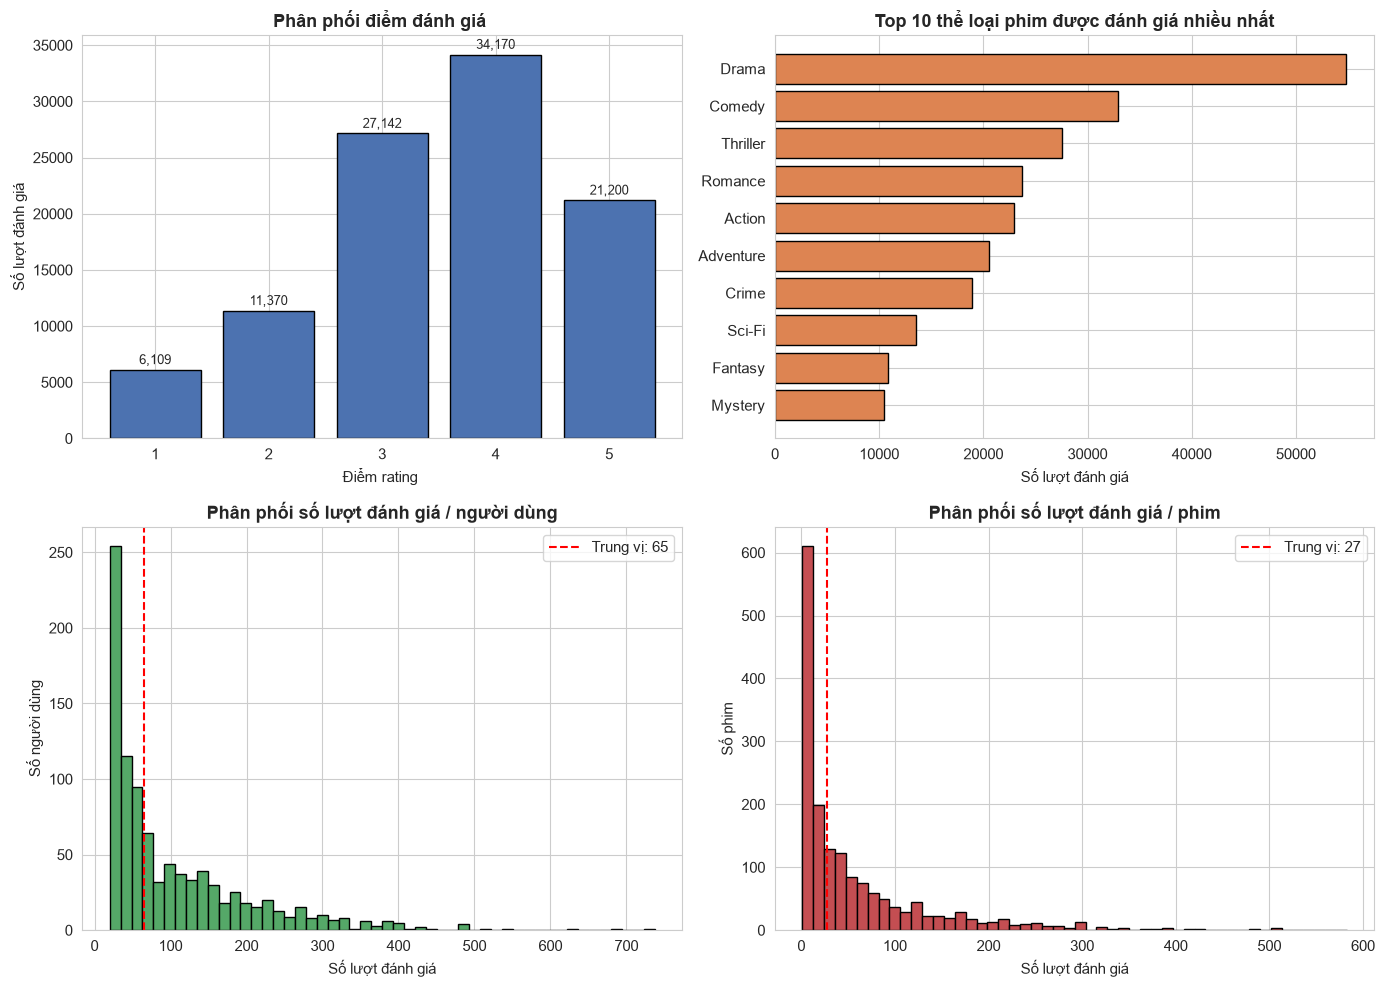

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Biểu đồ 1: Phân phối điểm rating
rating_counts = df['rating'].value_counts().sort_index()
axes[0, 0].bar(rating_counts.index, rating_counts.values, color='#4C72B0', edgecolor='black')
axes[0, 0].set_title('Phân phối điểm đánh giá ', fontweight='bold')
axes[0, 0].set_xlabel('Điểm rating ')
axes[0, 0].set_ylabel('Số lượt đánh giá')
for i, v in zip(rating_counts.index, rating_counts.values):
    axes[0, 0].text(i, v + 500, f'{v:,}', ha='center', fontsize=9)

# Biểu đồ 2: Top 10 thể loại phim được đánh giá nhiều nhất
all_genres = df.explode('genres_list')
genre_counts = all_genres[all_genres['genres_list'] != 'Unknown']['genres_list'].value_counts().head(10)
axes[0, 1].barh(genre_counts.index[::-1], genre_counts.values[::-1], color='#DD8452', edgecolor='black')
axes[0, 1].set_title('Top 10 thể loại phim được đánh giá nhiều nhất', fontweight='bold')
axes[0, 1].set_xlabel('Số lượt đánh giá')

# Biểu đồ 3: Số lượt đánh giá trên mỗi người dùng 
ratings_per_user = df.groupby('user_id').size()
axes[1, 0].hist(ratings_per_user, bins=50, color='#55A868', edgecolor='black')
axes[1, 0].set_title('Phân phối số lượt đánh giá / người dùng', fontweight='bold')
axes[1, 0].set_xlabel('Số lượt đánh giá')
axes[1, 0].set_ylabel('Số người dùng')
axes[1, 0].axvline(ratings_per_user.median(), color='red', linestyle='--',
                    label=f'Trung vị: {ratings_per_user.median():.0f}')
axes[1, 0].legend()

# Biểu đồ 4: Số lượt đánh giá trên mỗi phim
ratings_per_movie = df.groupby('movie_id').size()
axes[1, 1].hist(ratings_per_movie, bins=50, color='#C44E52', edgecolor='black')
axes[1, 1].set_title('Phân phối số lượt đánh giá / phim', fontweight='bold')
axes[1, 1].set_xlabel('Số lượt đánh giá')
axes[1, 1].set_ylabel('Số phim')
axes[1, 1].axvline(ratings_per_movie.median(), color='red', linestyle='--',
                    label=f'Trung vị: {ratings_per_movie.median():.0f}')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
summary = pd.DataFrame({
    'Chỉ số': [
        'Tổng số lượt đánh giá',
        'Số người dùng',
        'Số phim',
        'Điểm rating trung bình',
        'Độ thưa ma trận (Sparsity)',
        'Số lượt đánh giá TB / người dùng',
        'Số lượt đánh giá TB / phim'
    ],
    'Giá trị': [
        f"{n_ratings:,}",
        f"{n_users:,}",
        f"{n_movies:,}",
        f"{df['rating'].mean():.3f}",
        f"{sparsity*100:.3f}%",
        f"{ratings_per_user.mean():.1f}",
        f"{ratings_per_movie.mean():.1f}"
    ]
})
summary

,Chỉ số,Giá trị
0,Tổng số lượt đánh giá,"99,991"
1,Số người dùng,943
2,Số phim,"1,681"
3,Điểm rating trung bình,3.530
4,Độ thưa ma trận (Sparsity),93.692%
5,Số lượt đánh giá TB / người dùng,106.0
6,Số lượt đánh giá TB / phim,59.5


4. Chia dữ liệu Train / Validation / Test
Tỷ lệ: 72% Train - 8% Validation - 20% Test.

In [10]:
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Load or define df if not already defined
# df = pd.read_csv('your_data.csv')  # Uncomment and modify path as needed

if 'df' not in globals():
    df = pd.read_csv('movielens_cleaned.csv', encoding='utf-8-sig')

train_df, test_df = train_test_split(df, test_size=0.2, random_state=RANDOM_STATE)

val_split = int(0.9 * len(train_df))
val_perm = np.random.permutation(len(train_df))
tr_idx, va_idx = val_perm[:val_split], val_perm[val_split:]

train_only_df = train_df.iloc[tr_idx]
val_df = train_df.iloc[va_idx]

print(f"Train: {len(train_only_df):,} | Validation: {len(val_df):,} | Test: {len(test_df):,}")

global_mean = train_df['rating'].mean()
n_users = df['user_idx'].nunique()
n_movies = df['movie_idx'].nunique()

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

Train: 71,992 | Validation: 8,000 | Test: 19,999


5. Xây dựng các mô hình Baseline

Hai mô hình cơ sở: Item-based kNN** và **Matrix Factorization (SVD-style).

In [11]:
import time
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd

if 'df' not in globals():
    df = pd.read_csv('movielens_cleaned.csv', encoding='utf-8-sig')

n_users = df['user_idx'].nunique()
n_movies = df['movie_idx'].nunique()

# --- Item-based kNN: 'huấn luyện' = xây ma trận rating + tính ma trận tương đồng Cosine ---
t0_knn = time.time()

train_matrix = np.zeros((n_users, n_movies), dtype=float)
for u, i, r in zip(train_df['user_idx'], train_df['movie_idx'], train_df['rating']):
    train_matrix[u, i] = r

item_sim = cosine_similarity(train_matrix.T)
np.fill_diagonal(item_sim, 0)
K_NEIGHBORS = 20

knn_train_time = time.time() - t0_knn
print(f"Thời gian huấn luyện (xây dựng ma trận tương đồng) kNN: {knn_train_time:.4f} giây")

def predict_knn(u, i):
    user_rated = np.nonzero(train_matrix[u])[0]
    if len(user_rated) == 0:
        return global_mean
    sims = item_sim[i, user_rated]
    top_k_idx = np.argsort(sims)[-K_NEIGHBORS:]
    top_sims = sims[top_k_idx]
    top_ratings = train_matrix[u, user_rated[top_k_idx]]
    if top_sims.sum() <= 1e-8:
        return global_mean
    return np.dot(top_sims, top_ratings) / top_sims.sum()

Thời gian huấn luyện (xây dựng ma trận tương đồng) kNN: 0.0646 giây


In [12]:
# --- Matrix Factorization (Biased MF, SGD): đo thời gian huấn luyện toàn bộ vòng lặp epoch ---
import time

K = 20
N_EPOCHS_MF = 25
LR_MF = 0.01
REG_MF = 0.05

P = np.random.normal(0, 0.1, (n_users, K))
Q = np.random.normal(0, 0.1, (n_movies, K))
b_u = np.zeros(n_users)
b_i = np.zeros(n_movies)

train_u = train_df['user_idx'].values
train_i = train_df['movie_idx'].values
train_r = train_df['rating'].values

t0_mf = time.time()
for epoch in range(N_EPOCHS_MF):
    perm = np.random.permutation(len(train_u))
    for idx in perm:
        u, i, r = train_u[idx], train_i[idx], train_r[idx]
        pred = global_mean + b_u[u] + b_i[i] + np.dot(P[u], Q[i])
        err = r - pred
        b_u[u] += LR_MF * (err - REG_MF * b_u[u])
        b_i[i] += LR_MF * (err - REG_MF * b_i[i])
        P_u_old = P[u].copy()
        P[u] += LR_MF * (err * Q[i] - REG_MF * P[u])
        Q[i] += LR_MF * (err * P_u_old - REG_MF * Q[i])
mf_train_time = time.time() - t0_mf

print(f"Thời gian huấn luyện Matrix Factorization ({N_EPOCHS_MF} epoch): {mf_train_time:.4f} giây")

Thời gian huấn luyện Matrix Factorization (25 epoch): 24.2248 giây


6, 7. Huấn luyện mô hình NCF & Tối ưu siêu tham số

Kiến trúc NCF (GMF + MLP), tối ưu bằng Adam, có Early Stopping dựa trên Validation RMSE.

In [13]:
K_GMF, K_MLP = 8, 8
H1, H2 = 16, 8
N_EPOCHS_NCF = 40
BATCH_SIZE = 256
LR_NCF = 0.001
REG_NCF = 1e-4
PATIENCE = 5

def init_w(shape):
    return np.random.normal(0, np.sqrt(2.0 / shape[0]), shape)

params = {
    'P_gmf': np.random.normal(0, 0.1, (n_users, K_GMF)),
    'Q_gmf': np.random.normal(0, 0.1, (n_movies, K_GMF)),
    'P_mlp': np.random.normal(0, 0.1, (n_users, K_MLP)),
    'Q_mlp': np.random.normal(0, 0.1, (n_movies, K_MLP)),
    'W1': init_w((2 * K_MLP, H1)), 'b1': np.zeros(H1),
    'W2': init_w((H1, H2)), 'b2': np.zeros(H2),
    'Wout': init_w((K_GMF + H2, 1)), 'bout': np.zeros(1),
}
m_state = {k: np.zeros_like(v) for k, v in params.items()}
v_state = {k: np.zeros_like(v) for k, v in params.items()}
beta1, beta2, eps = 0.9, 0.999, 1e-8
t_step = 0

def relu(x): return np.maximum(0, x)
def relu_deriv(x): return (x > 0).astype(float)

def adam_update(key, grad):
    global t_step
    m_state[key] = beta1 * m_state[key] + (1 - beta1) * grad
    v_state[key] = beta2 * v_state[key] + (1 - beta2) * (grad ** 2)
    m_hat = m_state[key] / (1 - beta1 ** t_step)
    v_hat = v_state[key] / (1 - beta2 ** t_step)
    params[key] -= LR_NCF * m_hat / (np.sqrt(v_hat) + eps)

def ncf_predict(u_arr, i_arr):
    p_g, q_g = params['P_gmf'][u_arr], params['Q_gmf'][i_arr]
    gmf_vec = p_g * q_g
    p_m, q_m = params['P_mlp'][u_arr], params['Q_mlp'][i_arr]
    mlp_in = np.concatenate([p_m, q_m], axis=1)
    h1 = relu(mlp_in @ params['W1'] + params['b1'])
    h2 = relu(h1 @ params['W2'] + params['b2'])
    final_concat = np.concatenate([gmf_vec, h2], axis=1)
    pred = (final_concat @ params['Wout'] + params['bout']).flatten()
    return pred + global_mean

In [14]:
# --- Vòng lặp huấn luyện NCF với Early Stopping: đo thời gian huấn luyện toàn bộ ---
tr_u, tr_i, tr_r = train_only_df['user_idx'].values, train_only_df['movie_idx'].values, train_only_df['rating'].values
val_u, val_i, val_r = val_df['user_idx'].values, val_df['movie_idx'].values, val_df['rating'].values

best_val_rmse = np.inf
best_params = None
patience_counter = 0
n_train = len(tr_u)

t0_ncf = time.time()
for epoch in range(N_EPOCHS_NCF):
    perm = np.random.permutation(n_train)
    epoch_loss = 0.0
    for start in range(0, n_train, BATCH_SIZE):
        t_step += 1
        batch_idx = perm[start:start + BATCH_SIZE]
        u_b, i_b, r_b = tr_u[batch_idx], tr_i[batch_idx], tr_r[batch_idx] - global_mean
        bsz = len(u_b)

        p_g, q_g = params['P_gmf'][u_b], params['Q_gmf'][i_b]
        gmf_vec = p_g * q_g
        p_m, q_m = params['P_mlp'][u_b], params['Q_mlp'][i_b]
        mlp_in = np.concatenate([p_m, q_m], axis=1)
        z1 = mlp_in @ params['W1'] + params['b1']
        h1 = relu(z1)
        z2 = h1 @ params['W2'] + params['b2']
        h2 = relu(z2)
        final_concat = np.concatenate([gmf_vec, h2], axis=1)
        pred = (final_concat @ params['Wout'] + params['bout']).flatten()
        err = pred - r_b
        epoch_loss += np.sum(err ** 2)

        d_pred = (2 * err / bsz).reshape(-1, 1)
        grad_Wout = final_concat.T @ d_pred
        grad_bout = d_pred.sum(axis=0)
        d_final_concat = d_pred @ params['Wout'].T
        d_gmf_vec = d_final_concat[:, :K_GMF]
        d_h2 = d_final_concat[:, K_GMF:]
        d_z2 = d_h2 * relu_deriv(z2)
        grad_W2 = h1.T @ d_z2
        grad_b2 = d_z2.sum(axis=0)
        d_h1 = d_z2 @ params['W2'].T
        d_z1 = d_h1 * relu_deriv(z1)
        grad_W1 = mlp_in.T @ d_z1
        grad_b1 = d_z1.sum(axis=0)
        d_mlp_in = d_z1 @ params['W1'].T
        d_p_m, d_q_m = d_mlp_in[:, :K_MLP], d_mlp_in[:, K_MLP:]
        d_p_g = d_gmf_vec * q_g
        d_q_g = d_gmf_vec * p_g

        grad_P_gmf = np.zeros_like(params['P_gmf']); np.add.at(grad_P_gmf, u_b, d_p_g)
        grad_Q_gmf = np.zeros_like(params['Q_gmf']); np.add.at(grad_Q_gmf, i_b, d_q_g)
        grad_P_mlp = np.zeros_like(params['P_mlp']); np.add.at(grad_P_mlp, u_b, d_p_m)
        grad_Q_mlp = np.zeros_like(params['Q_mlp']); np.add.at(grad_Q_mlp, i_b, d_q_m)
        grad_P_gmf += REG_NCF * params['P_gmf']; grad_Q_gmf += REG_NCF * params['Q_gmf']
        grad_P_mlp += REG_NCF * params['P_mlp']; grad_Q_mlp += REG_NCF * params['Q_mlp']

        adam_update('Wout', grad_Wout); adam_update('bout', grad_bout)
        adam_update('W2', grad_W2); adam_update('b2', grad_b2)
        adam_update('W1', grad_W1); adam_update('b1', grad_b1)
        adam_update('P_gmf', grad_P_gmf); adam_update('Q_gmf', grad_Q_gmf)
        adam_update('P_mlp', grad_P_mlp); adam_update('Q_mlp', grad_Q_mlp)

    val_pred = np.clip(ncf_predict(val_u, val_i), 1, 5)
    val_rmse = rmse(val_r, val_pred)
    print(f"Epoch {epoch+1:2d}/{N_EPOCHS_NCF} - Train MSE: {epoch_loss/n_train:.4f} - Val RMSE: {val_rmse:.4f}")

    if val_rmse < best_val_rmse - 1e-4:
        best_val_rmse = val_rmse
        best_params = {k: v.copy() for k, v in params.items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"--> Early stopping tại epoch {epoch+1} (Val RMSE tốt nhất: {best_val_rmse:.4f})")
            break

ncf_train_time = time.time() - t0_ncf
params = best_params
print(f"\nThời gian huấn luyện NCF (đến khi Early Stopping): {ncf_train_time:.4f} giây")

Epoch  1/40 - Train MSE: 1.1864 - Val RMSE: 1.0101
Epoch  2/40 - Train MSE: 0.9148 - Val RMSE: 0.9593
Epoch  3/40 - Train MSE: 0.8497 - Val RMSE: 0.9504
Epoch  4/40 - Train MSE: 0.8242 - Val RMSE: 0.9459
Epoch  5/40 - Train MSE: 0.7973 - Val RMSE: 0.9399
Epoch  6/40 - Train MSE: 0.7500 - Val RMSE: 0.9321
Epoch  7/40 - Train MSE: 0.6964 - Val RMSE: 0.9331
Epoch  8/40 - Train MSE: 0.6515 - Val RMSE: 0.9381
Epoch  9/40 - Train MSE: 0.6157 - Val RMSE: 0.9467
Epoch 10/40 - Train MSE: 0.5887 - Val RMSE: 0.9537
Epoch 11/40 - Train MSE: 0.5669 - Val RMSE: 0.9609
--> Early stopping tại epoch 11 (Val RMSE tốt nhất: 0.9321)

Thời gian huấn luyện NCF (đến khi Early Stopping): 1.9865 giây


8, 9. Đánh giá mô hình RMSE/MAE và So sánh hiệu năng

Bài toán dự đoán rating là hồi quy nên dùng RMSE/MAE không dùng Accuracy/F1/AUC. Đánh giá cả 3 mô hình trên cùng tập Test.

In [15]:
test_u = test_df['user_idx'].values
test_i = test_df['movie_idx'].values
test_r = test_df['rating'].values

knn_preds = np.clip([predict_knn(u, i) for u, i in zip(test_u, test_i)], 1, 5)
mf_preds = np.clip(global_mean + b_u[test_u] + b_i[test_i] + np.sum(P[test_u]*Q[test_i], axis=1), 1, 5)
ncf_preds = np.clip(ncf_predict(test_u, test_i), 1, 5)

results = [
    ('Item-based kNN', rmse(test_r, knn_preds), mae(test_r, knn_preds), knn_train_time),
    ('Matrix Factorization (SVD)', rmse(test_r, mf_preds), mae(test_r, mf_preds), mf_train_time),
    ('NCF (GMF + MLP) - đề xuất', rmse(test_r, ncf_preds), mae(test_r, ncf_preds), ncf_train_time),
]

result_df = pd.DataFrame(results, columns=['Mô hình', 'RMSE', 'MAE', 'Thời gian huấn luyện (s)'])
result_df

,Mô hình,RMSE,MAE,Thời gian huấn luyện (s)
0,Item-based kNN,0.971243,0.758880,0.064587
1,Matrix Factorization (SVD),0.924668,0.727684,24.224826
2,NCF (GMF + MLP) - đề xuất,0.931588,0.735622,1.986481


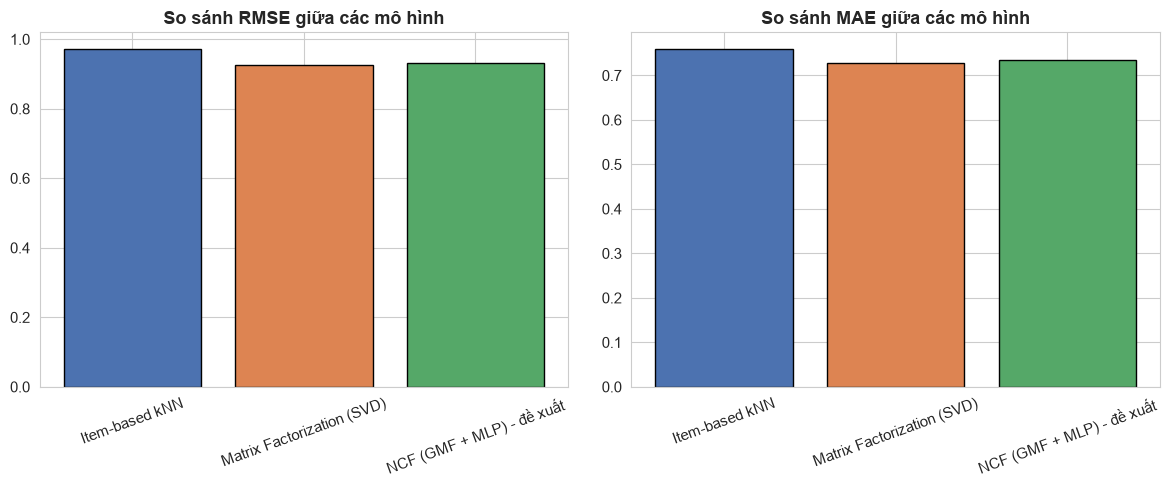

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#4C72B0', '#DD8452', '#55A868']

axes[0].bar(result_df['Mô hình'], result_df['RMSE'], color=colors, edgecolor='black')
axes[0].set_title('So sánh RMSE giữa các mô hình', fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(result_df['Mô hình'], result_df['MAE'], color=colors, edgecolor='black')
axes[1].set_title('So sánh MAE giữa các mô hình', fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('model_comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()